**Part 1. Data Analysis & Preprocessing**

In [354]:
# 1. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import warnings

In [355]:
# 2. Read, preprocess, and print the main statistics about the dataset.
warnings.filterwarnings('ignore')
df_penguin = pd.read_csv('./noisy_datasets/penguins.csv')
df_penguin.describe()

,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,344.000000,344.000000,337.000000,333.000000,336.000000,339.000000,342.000000
mean,5270.002907,10.447674,45.494214,18.018318,197.764881,4175.463127,2008.035088
std,1067.959116,2.265895,10.815787,9.241384,27.764491,858.713267,0.816938
min,3504.000000,7.000000,32.100000,13.100000,10.000000,882.000000,2007.000000
25%,4403.000000,9.000000,39.500000,15.700000,190.000000,3550.000000,2007.000000
50%,5106.500000,10.000000,45.100000,17.300000,197.000000,4050.000000,2008.000000
75%,6212.750000,12.000000,49.000000,18.700000,213.000000,4750.000000,2009.000000
max,7197.000000,14.000000,124.300000,127.260000,231.000000,6300.000000,2009.000000


In [356]:
# 3. Handle missing entries.
print(df_penguin.shape, df_penguin.dtypes)
for col in df_penguin.columns.unique():
    print(col, df_penguin[col].isna().sum())
# 'penguins' dataframe data is not big enough to neglige missing data. So I replace number type missing column data with median value.
object_columns = df_penguin.select_dtypes(include=['object'])
df_penguin_cleaned = df_penguin.dropna(subset=object_columns.columns)
num_columns = df_penguin.select_dtypes(include=['int64', 'float64'])
for col in num_columns:
    median = df_penguin_cleaned[col].median()
    df_penguin_cleaned[col].fillna(median, inplace=True)

(344, 10) species                    object
island                     object
calorie requirement         int64
average sleep duration      int64
bill_length_mm            float64
bill_depth_mm             float64
flipper_length_mm         float64
body_mass_g               float64
gender                     object
year                      float64
dtype: object
species 11
island 10
calorie requirement 0
average sleep duration 0
bill_length_mm 7
bill_depth_mm 11
flipper_length_mm 8
body_mass_g 5
gender 17
year 2


In [357]:
# 4. Handle mismatched string formats.
# check object_columns' values
for col in object_columns:
    print(col, df_penguin_cleaned[col].unique())
# make format consistent
df_penguin_cleaned['species'].replace({'gentoo': 'Gentoo', 'GENTOO': 'Gentoo', 'chinstrap': 'Chinstrap'}, inplace=True)
df_penguin_cleaned['island'].replace({'biscoe': 'Biscoe', 'BISCOE': 'Biscoe', 'dream': 'Dream', 'DREAM': 'Dream'}, inplace=True)
df_penguin_cleaned['gender'].replace({'MALE': 'male'}, inplace=True)

species ['Adelie' 'Gentoo' 'gentoo' 'GENTOO' 'Chinstrap' 'chinstrap']
island ['Torgersen' 'Biscoe' 'Dream' 'biscoe' 'BISCOE' 'dream' 'DREAM']
gender ['male' 'female' 'MALE']


In [358]:
# 5. Handle outliers.
# Find number type columns' outliers using IQR
outliers = set()
for col in num_columns:
    q1 = df_penguin_cleaned[col].quantile(0.25)
    q3 = df_penguin_cleaned[col].quantile(0.75)
    iqr = q3 - q1

    outliers = outliers | set(df_penguin_cleaned[df_penguin_cleaned[col] < q1 - 1.5 * iqr].index.to_list())
df_penguin_cleaned = df_penguin_cleaned.drop(index=list(outliers))

In [359]:
df_penguin_cleaned.head(15)


,species,island,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,gender,year
0,Adelie,Torgersen,6563,11,39.1,18.7,181.0,3750.0,male,2007.0
1,Adelie,Torgersen,4890,14,39.5,17.4,186.0,3800.0,female,2007.0
2,Adelie,Torgersen,7184,11,40.3,18.0,195.0,3250.0,female,2007.0
4,Adelie,Torgersen,4774,8,36.7,19.3,193.0,3450.0,female,2007.0
5,Adelie,Torgersen,4403,13,39.3,20.6,190.0,3650.0,male,2007.0
6,Adelie,Torgersen,5071,11,38.9,17.8,181.0,3625.0,female,2007.0
7,Adelie,Torgersen,6799,9,39.2,19.6,195.0,4675.0,male,2007.0
12,Adelie,Torgersen,6644,12,41.1,17.6,182.0,3200.0,female,2007.0
13,Adelie,Torgersen,4812,10,38.6,21.2,191.0,3800.0,male,2007.0
14,Adelie,Torgersen,4615,9,34.6,21.1,198.0,4400.0,male,2007.0


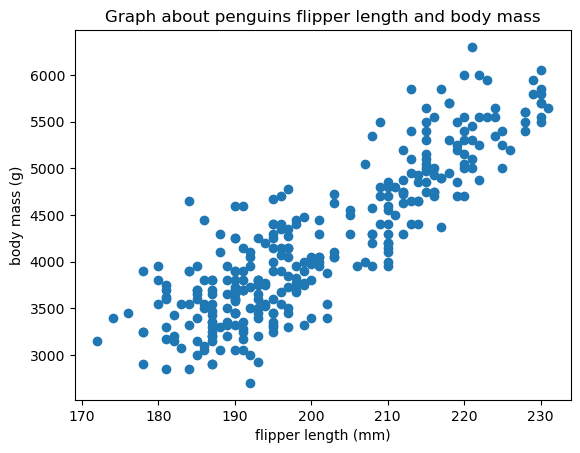

In [360]:
# 6. Using any data visualization library (e.g. matplotlib, seaborn, plotly), provide at least 5 visualization graphs related to your dataset.
# graph 1: graph about penguins flipper length and body mass
plt.scatter(df_penguin_cleaned['flipper_length_mm'], df_penguin_cleaned['body_mass_g'])
plt.title("Graph about penguins flipper length and body mass")
plt.xlabel("flipper length (mm)")
plt.ylabel("body mass (g)")
plt.show()

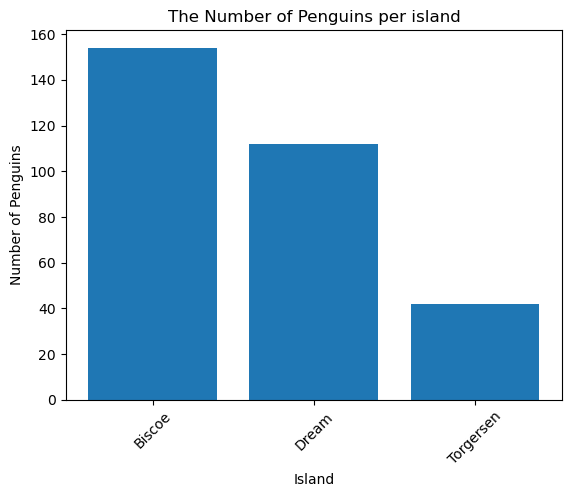

In [361]:
# graph 2: graph about the Number of Penguins per island
species_count = df_penguin_cleaned.groupby('island')['island'].count()
plt.bar(species_count.index, species_count.values)
plt.title('The Number of Penguins per island')
plt.xlabel('Island')
plt.ylabel('Number of Penguins')
plt.xticks(rotation=45)
plt.show()

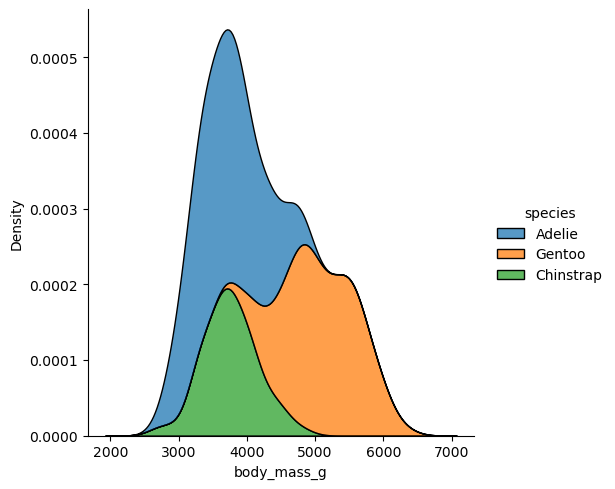

In [362]:
# graph 3: graph about body mass distribution by species
sns.displot(data=df_penguin_cleaned, x="body_mass_g", hue="species", multiple="stack", kind="kde")

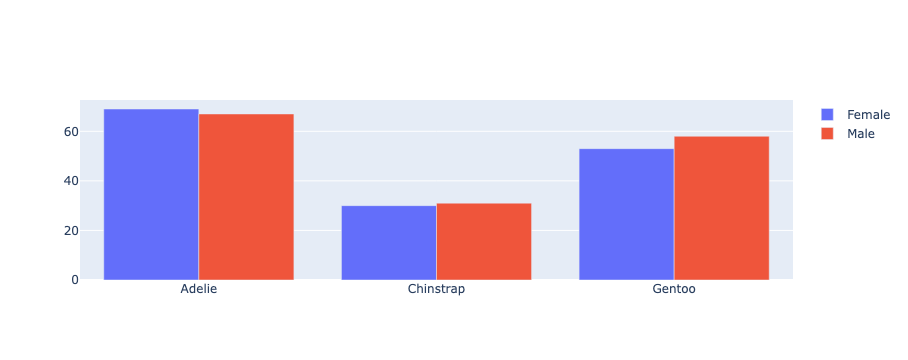

In [363]:
# graph 4: Graph about gender and species
fig = go.Figure()
fm_species_count = df_penguin_cleaned[df_penguin_cleaned['gender'] == 'female'].groupby('species')['species'].count()
m_species_count = df_penguin_cleaned[df_penguin_cleaned['gender'] == 'male'].groupby('species')['species'].count()

species = list(df_penguin_cleaned['species'].unique())
fig = go.Figure(data=[
    go.Bar(name='Female', x=fm_species_count.index, y=fm_species_count.values),
    go.Bar(name='Male', x=fm_species_count.index, y=m_species_count.values)
])
fig.update_layout(barmode='group')
fig.show()

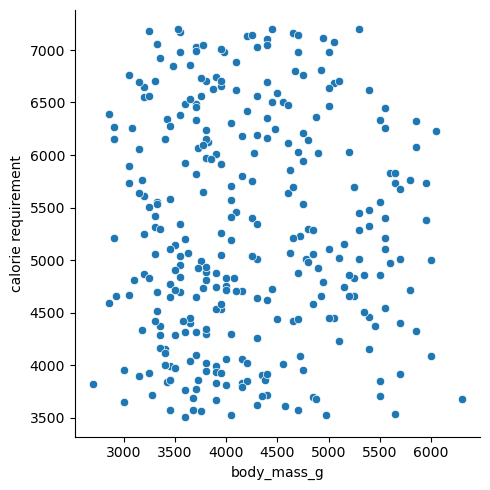

In [364]:
# graph 5: Graph about body mass and calorie requirement
sns.relplot(data=df_penguin_cleaned, x="body_mass_g", y="calorie requirement")

In [365]:
# 8. Convert features with string datatype to categorical (e.g., species, island).
for col in object_columns:
    df_penguin_cleaned[col] = df_penguin_cleaned[col].astype('category')
df_encoded = pd.get_dummies(df_penguin_cleaned, drop_first=False)

In [366]:
bool_columns = df_encoded.select_dtypes(include=['bool'])
for col in bool_columns:
    df_encoded[col] = df_encoded[col].astype('int')

In [367]:
# 7. Identify uncorrelated or unrelated features.
df_encoded.corr(method='pearson')

,calorie requirement,average sleep duration,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,gender_female,gender_male
calorie requirement,1.000000,-0.048562,0.039651,-0.054758,-0.004974,0.011708,-0.012189,0.018890,-0.074103,0.041973,0.045601,-0.066114,0.026236,0.020595,-0.020595
average sleep duration,-0.048562,1.000000,0.068987,0.037851,0.068069,0.085338,0.021148,0.015250,-0.044627,0.021271,0.008681,-0.037460,0.039861,-0.080956,0.080956
bill_length_mm,0.039651,0.068987,1.000000,-0.018412,0.519763,0.460788,0.074527,-0.707745,0.427394,0.377238,0.145496,0.065698,-0.304077,-0.262571,0.262571
bill_depth_mm,-0.054758,0.037851,-0.018412,1.000000,-0.110384,-0.072337,-0.084508,0.104354,0.069950,-0.165996,-0.125236,0.093575,0.051298,-0.163115,0.163115
flipper_length_mm,-0.004974,0.068069,0.519763,-0.110384,1.000000,0.870929,0.164086,-0.688787,-0.174639,0.857364,0.585061,-0.410474,-0.277041,-0.275467,0.275467
body_mass_g,0.011708,0.085338,0.460788,-0.072337,0.870929,1.000000,0.035908,-0.559757,-0.285427,0.815874,0.609529,-0.454801,-0.250556,-0.442502,0.442502
year,-0.012189,0.021148,0.074527,-0.084508,0.164086,0.035908,1.000000,0.006616,-0.048088,0.033074,0.072278,-0.059190,-0.022338,-0.015333,0.015333
species_Adelie,0.018890,0.015250,-0.707745,0.104354,-0.688787,-0.559757,0.006616,1.000000,-0.441898,-0.667473,-0.326916,0.021006,0.446867,0.024627,-0.024627
species_Chinstrap,-0.074103,-0.044627,0.427394,0.069950,-0.174639,-0.285427,-0.048088,-0.441898,1.000000,-0.373031,-0.496954,0.657409,-0.197470,-0.001693,0.001693
species_Gentoo,0.041973,0.021271,0.377238,-0.165996,0.857364,0.815874,0.033074,-0.667473,-0.373031,1.000000,0.750634,-0.567426,-0.298272,-0.024066,0.024066


In [368]:
# Drop features with a low correlation coefficient with target(island_Biscoe) to enhance model performance.
df_encoded = df_encoded.drop(columns=['calorie requirement', 'average sleep duration', 'year', 'gender_female', 'gender_male'])

In [370]:
# 9. Normalize non-categorical features (e.g. bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g).
num_columns = df_encoded.select_dtypes(include=['int64', 'float64'])
for col in num_columns:
    min_value = df_encoded[col].min()
    max_value = df_encoded[col].max()
    df_encoded[col] = (df_encoded[col] - min_value) / (max_value - min_value)

In [371]:
df_encoded.to_csv('./preprocessed_datasets/penguins_preprocessed.csv', index=False)

Using diamond data

In [372]:
df_diamond = pd.read_csv('./noisy_datasets/diamond.csv', index_col=False)
df_diamond.describe()
df_diamond.head(10)

,Unnamed: 0,carat,cut,color,clarity,average us salary,number of diamonds mined (millions),depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,31282,5.01,61.5,55,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,40049,1.69,59.8,61,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,33517,3.85,56.9,65,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,38495,3.49,62.4,58,334,4.2,4.23,2.63
4,5,0.31,Good,J,SI2,34178,4.70,63.3,58,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,44700,0.86,62.8,57,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,42939,1.68,62.3,57,336,3.95,3.98,2.47
7,8,FALSE,NaN,H,SI1,37587,4.62,MAYBE,MAYBE,NaN,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,30454,4.02,65.1,61,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,45506,1.20,59.4,61,338,4,4.05,2.39


In [373]:
# 3. Handle missing entries.
# 'df_diamond' dataframe is big enough to neglige missing data. So I dropped rows containing missing value.
print(df_diamond.shape, df_diamond.dtypes)
for col in df_diamond.columns.unique():
    print(col, df_diamond[col].isna().sum())
df_diamond_preprocessed = df_diamond.drop(columns='Unnamed: 0')
df_diamond_preprocessed = df_diamond_preprocessed.dropna(axis=0)

(53940, 13) Unnamed: 0                              object
carat                                   object
cut                                     object
color                                   object
clarity                                 object
average us salary                        int64
number of diamonds mined (millions)    float64
depth                                   object
table                                   object
price                                   object
x                                       object
y                                       object
z                                       object
dtype: object
Unnamed: 0 377
carat 1510
cut 1293
color 1512
clarity 353
average us salary 0
number of diamonds mined (millions) 0
depth 694
table 1542
price 1583
x 1526
y 1221
z 1433


In [374]:
# 4. Handle mismatched string formats.
# check object_columns' values
object_columns = df_diamond_preprocessed.select_dtypes(include=['object'])
num_columns = df_diamond_preprocessed.select_dtypes(include=['int64', 'float64'])
for col in object_columns:
    print(col, df_diamond_preprocessed[col].unique())
df_diamond_preprocessed = df_diamond_preprocessed[df_diamond_preprocessed.isin(['TRUE', 'FALSE', 'MAYBE']).any(axis=1) == False]
df_diamond_preprocessed['cut'] = df_diamond_preprocessed['cut'].replace({'IDEAL': 'Ideal', 'VERY GOOD': 'Very Good', 'GOOD': 'Good', 'very good': 'Very Good', 'ideal': 'Ideal', 'premium': 'Premium', 'PREMIUM': 'Premium', 'good': 'Good', 'FAIR': 'Fair'})
df_diamond_preprocessed['color'] = df_diamond_preprocessed['color'].replace({'e': 'E', 'i': 'I', 'j': 'J', 'h': 'H', 'g': 'G', 'd': 'D', 'f': 'F'})
df_diamond_preprocessed['clarity'] = df_diamond_preprocessed['clarity'].replace({'si2': 'SI2', 'vvs2': 'VVS2', 'si1': 'SI1', 'vs2': 'VS2', 'vs1': 'VS1'})
df_diamond_preprocessed['carat'] = df_diamond_preprocessed['carat'].astype('float64')
df_diamond_preprocessed['depth'] = df_diamond_preprocessed['depth'].astype('float64')
df_diamond_preprocessed['table'] = df_diamond_preprocessed['table'].astype('float64')
df_diamond_preprocessed['price'] = df_diamond_preprocessed['price'].astype('float64')
df_diamond_preprocessed['x'] = df_diamond_preprocessed['x'].astype('float64')
df_diamond_preprocessed['y'] = df_diamond_preprocessed['y'].astype('float64')
df_diamond_preprocessed['z'] = df_diamond_preprocessed['z'].astype('float64')


carat ['0.23' '0.21' '0.29' '0.31' '0.24' '0.22' '0.3' '0.2' '0.32' '0.26'
 '0.33' '0.25' '0.35' '0.42' '0.28' '0.38' '0.7' '0.86' '0.71' '0.78'
 '0.8' '0.75' '0.74' '0.81' '0.59' '0.9' '0.73' '0.91' '0.61' '0.77'
 '0.76' '0.64' '0.72' '0.79' '0.58' '1.17' '0.6' '0.83' 'TRUE' '0.54'
 '0.98' '0.52' '0.53' '0.51' '1.01' '1.05' '0.55' '0.63' '0.87' '1' '0.57'
 '0.82' '0.96' '1.04' '0.93' '1.2' '0.99' '0.34' '0.43' '0.36' '0.84'
 '0.89' '1.02' '0.56' '0.85' '0.92' '0.95' '1.27' '0.66' '1.12' '0.68'
 '1.03' '0.97' '0.62' '1.22' '1.08' '0.88' '0.5' '1.19' '0.39' '0.65'
 '1.24' '1.5' '0.27' '0.41' '1.13' '1.06' '0.69' '0.4' '1.14' '0.94'
 '1.29' '1.52' '1.16' '1.21' 'MAYBE' '1.23' '1.09' '0.67' '1.11' '1.1'
 '1.18' '1.15' '1.25' '1.07' '1.28' 'FALSE' '1.51' '0.37' '1.31' '1.26'
 '1.39' '1.44' '1.35' '1.3' '1.41' '1.36' '1.32' '1.45' '1.58' '1.54'
 '1.34' '1.38' '1.33' '1.74' '1.47' '1.55' '1.95' '2' '1.37' '1.83' '1.62'
 '1.57' '1.69' '2.06' '1.72' '1.66' '2.14' '1.49' '1.46' '2.15' '1.96'
 '

In [375]:
# 5. Handle outliers.
# Find number type columns' outliers using IQR
object_columns = df_diamond_preprocessed.select_dtypes(include=['object'])
num_columns = df_diamond_preprocessed.select_dtypes(include=['int64', 'float64'])
outliers = set()
for col in num_columns:
    q1 = df_diamond_preprocessed[col].quantile(0.25)
    q3 = df_diamond_preprocessed[col].quantile(0.75)
    iqr = q3 - q1

    outliers = outliers | set(df_diamond_preprocessed[df_diamond_preprocessed[col] < q1 - 1.5 * iqr].index.to_list())
df_diamond_preprocessed = df_diamond_preprocessed.drop(index=list(outliers))

In [376]:
df_diamond_preprocessed.head(15)

,carat,cut,color,clarity,average us salary,number of diamonds mined (millions),depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,31282,5.01,61.5,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,40049,1.69,59.8,61.0,326.0,3.89,3.84,2.31
3,0.29,Premium,I,VS2,38495,3.49,62.4,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,34178,4.70,63.3,58.0,335.0,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,44700,0.86,62.8,57.0,336.0,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,42939,1.68,62.3,57.0,336.0,3.95,3.98,2.47
8,0.22,Fair,E,VS2,30454,4.02,65.1,61.0,337.0,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,45506,1.20,59.4,61.0,338.0,4.00,4.05,2.39
10,0.30,Good,J,SI1,38031,2.63,64.0,55.0,339.0,4.25,4.28,2.73
11,0.23,Ideal,J,VS1,44410,2.39,62.8,56.0,340.0,3.93,3.90,2.46


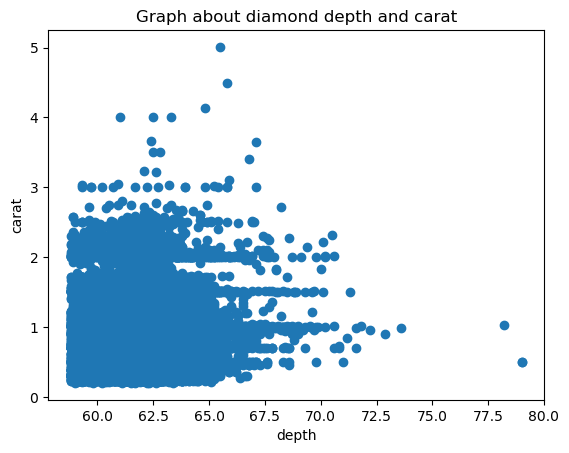

In [377]:
# 6. Using any data visualization library (e.g. matplotlib, seaborn, plotly), provide at least 5 visualization graphs related to your dataset.
# graph 1: graph about depth and carat
plt.scatter(df_diamond_preprocessed['depth'], df_diamond_preprocessed['carat'])
plt.title("Graph about diamond depth and carat")
plt.xlabel("depth")
plt.ylabel("carat")
plt.show()

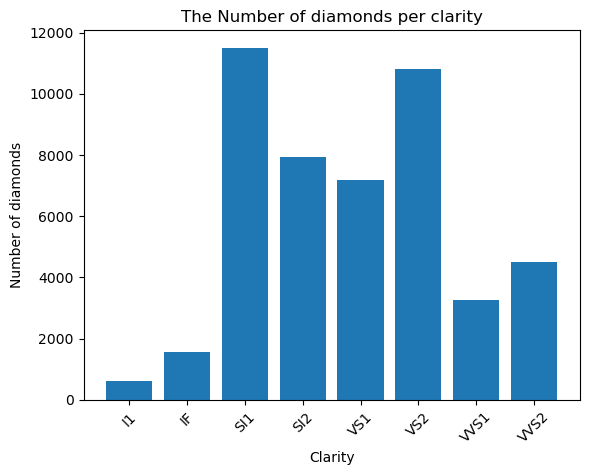

In [378]:
# graph 2: graph about diamond clarity
clarity_count = df_diamond_preprocessed.groupby('clarity')['clarity'].count()
plt.bar(clarity_count.index, clarity_count.values)
plt.title('The Number of diamonds per clarity')
plt.xlabel('Clarity')
plt.ylabel('Number of diamonds')
plt.xticks(rotation=45)
plt.show()

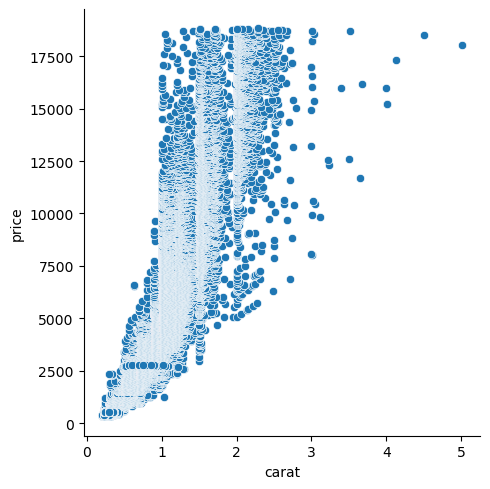

In [379]:
# graph3: graph about 
sns.relplot(data=df_diamond_preprocessed, x="carat", y="price")

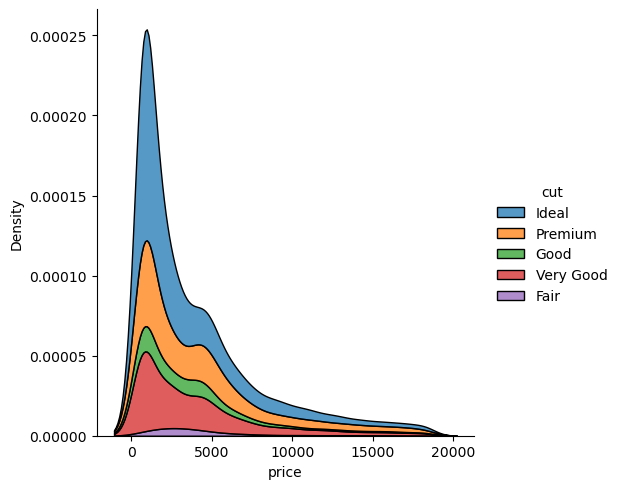

In [380]:
# graph 4: graph about diamond cut and price
sns.displot(data=df_diamond_preprocessed, x="price", hue="cut", multiple="stack", kind="kde")

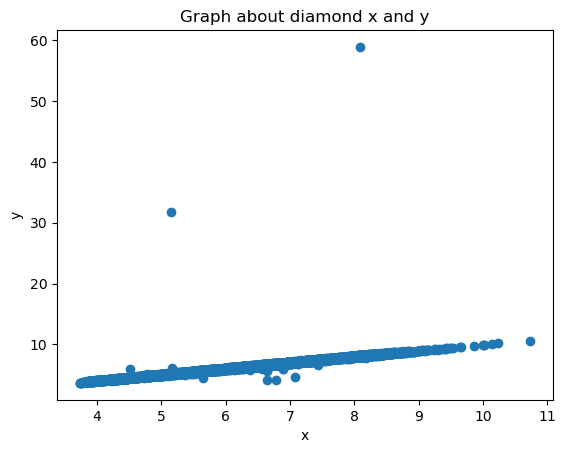

In [381]:
# graph 5: graph about diamond x and y
plt.scatter(df_diamond_preprocessed['x'], df_diamond_preprocessed['y'])
plt.title("Graph about diamond x and y")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [382]:
# 8. Convert features with string datatype to categorical.
for col in object_columns:
    df_diamond_preprocessed[col] = df_diamond_preprocessed[col].astype('category')
df_diamond_preprocessed = pd.get_dummies(df_diamond_preprocessed, drop_first=False)

In [383]:
bool_columns = df_diamond_preprocessed.select_dtypes(include=['bool'])
for col in bool_columns:
    df_diamond_preprocessed[col] = df_diamond_preprocessed[col].astype('int')

In [384]:
# 7. Identify uncorrelated or unrelated features.
df_diamond_preprocessed.corr(method='pearson')

,carat,average us salary,number of diamonds mined (millions),depth,table,price,x,y,z,cut_Fair,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
carat,1.000000,0.006572,-0.011039,0.060215,0.179564,0.921966,0.978097,0.951070,0.959750,0.097925,...,0.159517,0.179490,0.121497,-0.114358,0.063021,0.267104,-0.059478,-0.038885,-0.166925,-0.136793
average us salary,0.006572,1.000000,0.001695,-0.001222,0.001249,0.007877,0.005570,0.004704,0.005762,-0.007072,...,-0.002193,-0.003755,-0.001622,-0.004859,0.002805,-0.002385,0.000051,0.010562,-0.005144,-0.008192
number of diamonds mined (millions),-0.011039,0.001695,1.000000,-0.001889,-0.001772,-0.011150,-0.009115,-0.010604,-0.009068,-0.006432,...,-0.003829,-0.005078,-0.003031,-0.002879,-0.000043,-0.005967,0.000933,0.007853,-0.002547,0.000426
depth,0.060215,-0.001222,-0.001889,1.000000,-0.203938,0.000993,0.014794,0.007296,0.119541,0.439202,...,0.027120,0.028153,0.114959,-0.041716,0.047209,0.032195,-0.031623,-0.018019,-0.038728,-0.031432
table,0.179564,0.001249,-0.001772,-0.203938,1.000000,0.128634,0.186861,0.175222,0.157073,0.075080,...,0.020241,0.034041,0.035677,-0.080660,0.056845,0.089250,-0.027910,-0.003577,-0.068248,-0.062969
price,0.921966,0.007877,-0.011150,0.000993,0.128634,1.000000,0.888794,0.866369,0.866766,0.022195,...,0.093882,0.081085,0.000960,-0.050021,0.007536,0.129492,-0.006599,-0.001841,-0.094956,-0.052733
x,0.978097,0.005570,-0.009115,0.014794,0.186861,0.888794,1.000000,0.971704,0.975324,0.079913,...,0.144733,0.163904,0.107329,-0.126062,0.079536,0.270386,-0.055798,-0.035280,-0.183988,-0.147311
y,0.951070,0.004704,-0.010604,0.007296,0.175222,0.866369,0.971704,1.000000,0.953837,0.068093,...,0.140428,0.159381,0.099375,-0.120495,0.075953,0.261777,-0.052178,-0.035555,-0.177288,-0.141244
z,0.959750,0.005762,-0.009068,0.119541,0.157073,0.866766,0.975324,0.953837,1.000000,0.122916,...,0.143339,0.162786,0.116229,-0.126090,0.080994,0.265730,-0.055363,-0.037204,-0.182392,-0.146141
cut_Fair,0.097925,-0.007072,-0.006432,0.439202,0.075080,0.022195,0.079913,0.068093,0.122916,1.000000,...,0.005832,0.018873,0.191716,-0.028590,0.003293,0.060365,-0.026327,-0.028050,-0.041533,-0.030838


In [385]:
# Drop features with a low correlation coefficient with target(cut_Ideal) to enhance model performance.
df_diamond_preprocessed = df_diamond_preprocessed.drop(columns=['average us salary', 'number of diamonds mined (millions)', 'color_D', 'color_E', 'color_F', 'color_G', 'color_H', 'color_I', 'color_J'])

In [386]:
# 9. Normalize non-categorical feature.
num_columns = df_diamond_preprocessed.select_dtypes(include=['int64', 'float64'])
for col in num_columns:
    min_value = df_diamond_preprocessed[col].min()
    max_value = df_diamond_preprocessed[col].max()
    df_diamond_preprocessed[col] = (df_diamond_preprocessed[col] - min_value) / (max_value - min_value)

In [387]:
df_diamond_preprocessed.to_csv('./preprocessed_datasets/df_diamond_preprocessed.csv', index=False)

Using wine data

In [388]:
df_wine_white = pd.read_csv('./noisy_datasets/wine_quality/winequality-white.csv', sep=';')
df_wine_red = pd.read_csv('./noisy_datasets/wine_quality/winequality-red.csv', sep=';')

df_wine_white['type'] = 'white'
df_wine_red['type'] = 'red'

df_wine = pd.concat([df_wine_white, df_wine_red])

In [390]:
df_wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [391]:
df_wine.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6,white
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,white
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,white
9,8.1,0.22,0.43,1.5,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6,white


In [392]:
# 3. Handle missing entries.
# 4. Handle mismatched string formats.
# wine dataset does not have a missing or mismatched value.
print(df_wine.shape, df_wine.dtypes)
for col in df_wine.columns.unique():
    print(col, df_wine[col].isna().sum())

(6497, 13) fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object
fixed acidity 0
volatile acidity 0
citric acid 0
residual sugar 0
chlorides 0
free sulfur dioxide 0
total sulfur dioxide 0
density 0
pH 0
sulphates 0
alcohol 0
quality 0
type 0


In [393]:
# 5. Handle outliers.
# Find number type columns' outliers using IQR
object_columns = df_wine.select_dtypes(include=['object'])
num_columns = df_wine.select_dtypes(include=['int64', 'float64'])
outliers = set()
for col in num_columns:
    q1 = df_wine[col].quantile(0.25)
    q3 = df_wine[col].quantile(0.75)
    iqr = q3 - q1

    outliers = outliers | set(df_wine[df_wine[col] < q1 - 1.5 * iqr].index.to_list())
df_wine_preprocessed = df_wine.drop(index=list(outliers))

In [394]:
df_wine_preprocessed.head(15)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,white
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,white
6,6.2,0.32,0.16,7.00,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6,white
9,8.1,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6,white
10,8.1,0.27,0.41,1.45,0.033,11.0,63.0,0.9908,2.99,0.56,12.0,5,white
11,8.6,0.23,0.40,4.20,0.035,17.0,109.0,0.9947,3.14,0.53,9.7,5,white
13,6.6,0.16,0.40,1.50,0.044,48.0,143.0,0.9912,3.54,0.52,12.4,7,white
14,8.3,0.42,0.62,19.25,0.040,41.0,172.0,1.0002,2.98,0.67,9.7,5,white
15,6.6,0.17,0.38,1.50,0.032,28.0,112.0,0.9914,3.25,0.55,11.4,7,white
16,6.3,0.48,0.04,1.10,0.046,30.0,99.0,0.9928,3.24,0.36,9.6,6,white


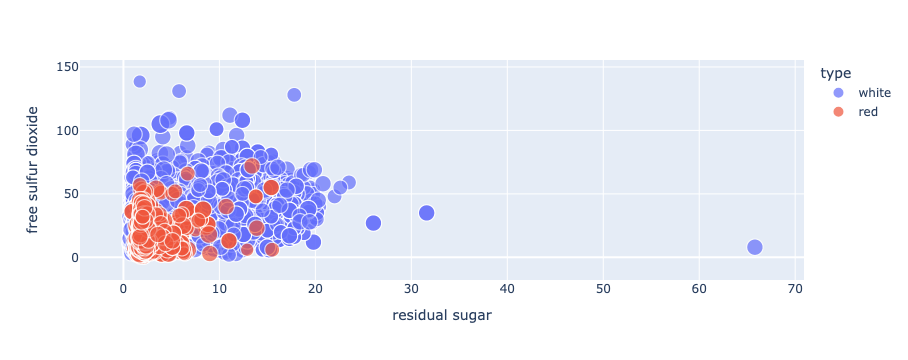

In [395]:
# 6. Using any data visualization library (e.g. matplotlib, seaborn, plotly), provide at least 5 visualization graphs related to your dataset.
# graph 1: graph about residual sugar and free sulfur dioxide
fig = px.scatter(df_wine_preprocessed, x="residual sugar", y="free sulfur dioxide", color="type",
                 size='quality', hover_data=['citric acid'])
fig.show()

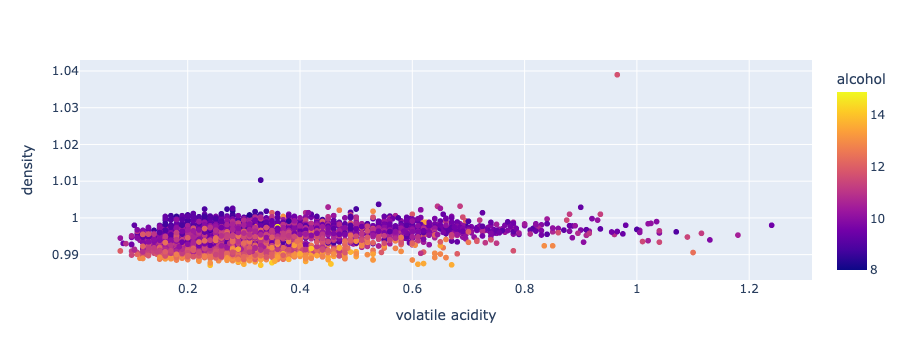

In [396]:
# graph 2:
fig = px.scatter(df_wine_preprocessed, x="volatile acidity", y="density", color='alcohol')
fig.show()

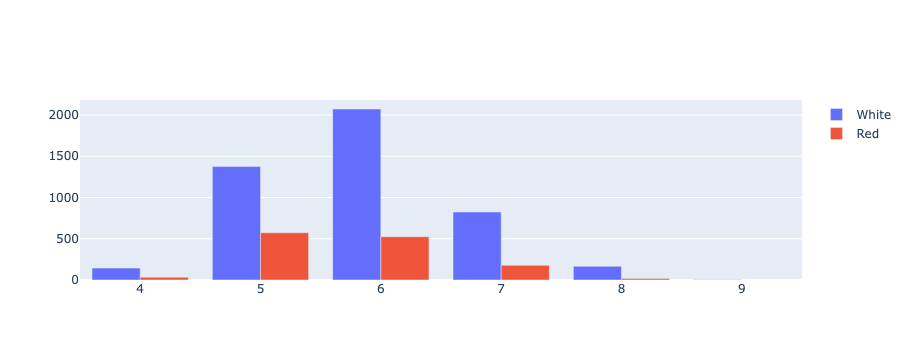

In [397]:
# graph 3: Graph about wine type and qualitay
fig = go.Figure()
white_wine_count = df_wine_preprocessed[df_wine_preprocessed['type'] == 'white'].groupby('quality')['quality'].count()
red_wine_count = df_wine_preprocessed[df_wine_preprocessed['type'] == 'red'].groupby('quality')['quality'].count()

type = list(df_wine_preprocessed['quality'].unique())
fig = go.Figure(data=[
    go.Bar(name='White', x=white_wine_count.index, y=white_wine_count.values),
    go.Bar(name='Red', x=red_wine_count.index, y=red_wine_count.values)
])

fig.update_layout(barmode='group')
fig.show()

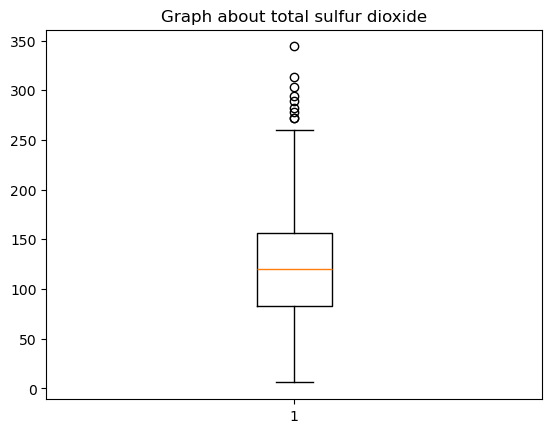

In [398]:
# graph 4: graph about total sulfur dioxide
plt.boxplot( df_wine_preprocessed['total sulfur dioxide'])
plt.title("Graph about total sulfur dioxide")
plt.show()

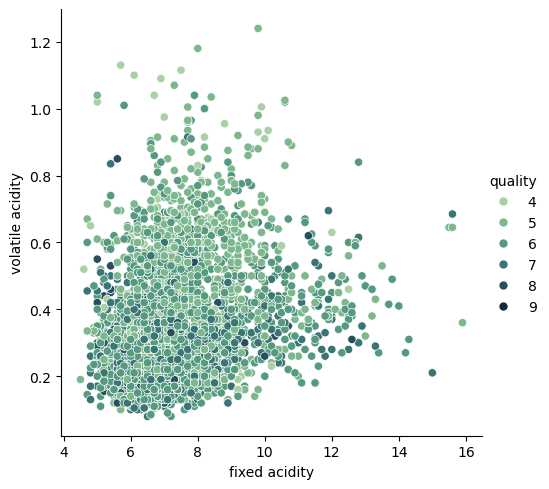

In [399]:
# graph 5: graph about fixed acidity and volatile acidity
sns.relplot(
    data=df_wine_preprocessed,
    x="fixed acidity", y="volatile acidity",
    hue="quality", palette="ch:r=-.5,l=.75"
)

In [400]:
# 8. Convert features with string datatype to categorical.
df_wine_preprocessed['type'] = df_wine_preprocessed['type'].astype('category')
df_wine_preprocessed = pd.get_dummies(df_wine_preprocessed, drop_first=False)

In [401]:
df_wine_preprocessed.head(15)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_red,type_white
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,False,True
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,False,True
6,6.2,0.32,0.16,7.00,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6,False,True
9,8.1,0.22,0.43,1.50,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6,False,True
10,8.1,0.27,0.41,1.45,0.033,11.0,63.0,0.9908,2.99,0.56,12.0,5,False,True
11,8.6,0.23,0.40,4.20,0.035,17.0,109.0,0.9947,3.14,0.53,9.7,5,False,True
13,6.6,0.16,0.40,1.50,0.044,48.0,143.0,0.9912,3.54,0.52,12.4,7,False,True
14,8.3,0.42,0.62,19.25,0.040,41.0,172.0,1.0002,2.98,0.67,9.7,5,False,True
15,6.6,0.17,0.38,1.50,0.032,28.0,112.0,0.9914,3.25,0.55,11.4,7,False,True
16,6.3,0.48,0.04,1.10,0.046,30.0,99.0,0.9928,3.24,0.36,9.6,6,False,True


In [402]:
bool_columns = df_wine_preprocessed.select_dtypes(include=['bool'])
for col in bool_columns:
    df_wine_preprocessed[col] = df_wine_preprocessed[col].astype('int')

In [403]:
# 7. Identify uncorrelated or unrelated features.
df_wine_preprocessed.corr(method='pearson')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_red,type_white
fixed acidity,1.000000,0.266986,0.342004,-0.124863,0.312937,-0.306367,-0.363141,0.464202,-0.230926,0.325877,-0.082814,-0.073678,0.542035,-0.542035
volatile acidity,0.266986,1.000000,-0.243766,-0.168178,0.370180,-0.335019,-0.355319,0.275574,0.184085,0.228453,-0.050647,-0.252708,0.621547,-0.621547
citric acid,0.342004,-0.243766,1.000000,0.092014,0.094937,0.075634,0.085847,0.137019,-0.242390,0.103803,0.000574,0.054594,-0.051710,0.051710
residual sugar,-0.124863,-0.168178,0.092014,1.000000,-0.122848,0.406561,0.489862,0.566400,-0.248009,-0.186283,-0.371014,-0.049863,-0.335796,0.335796
chlorides,0.312937,0.370180,0.094937,-0.122848,1.000000,-0.189961,-0.268208,0.359946,0.024918,0.388499,-0.262920,-0.191736,0.512398,-0.512398
free sulfur dioxide,-0.306367,-0.335019,0.075634,0.406561,-0.189961,1.000000,0.718652,0.036606,-0.124768,-0.196482,-0.193319,0.052621,-0.469271,0.469271
total sulfur dioxide,-0.363141,-0.355319,0.085847,0.489862,-0.268208,0.718652,1.000000,0.049778,-0.190279,-0.278616,-0.283426,-0.067706,-0.681054,0.681054
density,0.464202,0.275574,0.137019,0.566400,0.359946,0.036606,0.049778,1.000000,0.002906,0.259586,-0.689938,-0.307469,0.393207,-0.393207
pH,-0.230926,0.184085,-0.242390,-0.248009,0.024918,-0.124768,-0.190279,0.002906,1.000000,0.178074,0.106985,0.031027,0.273634,-0.273634
sulphates,0.325877,0.228453,0.103803,-0.186283,0.388499,-0.196482,-0.278616,0.259586,0.178074,1.000000,-0.009880,0.038123,0.498325,-0.498325


In [405]:
# Drop features with a low correlation coefficient with target(type_red) to enhance model performance.
df_wine_preprocessed = df_wine_preprocessed.drop(columns=['citric acid', 'alcohol', 'quality'])

In [406]:
# 9. Normalize non-categorical feature.
num_columns = df_wine_preprocessed.select_dtypes(include=['int64', 'float64'])
for col in num_columns:
    min_value = df_wine_preprocessed[col].min()
    max_value = df_wine_preprocessed[col].max()
    df_wine_preprocessed[col] = (df_wine_preprocessed[col] - min_value) / (max_value - min_value)

In [407]:
df_wine_preprocessed.to_csv('./preprocessed_datasets/df_wine_preprocessed.csv', index=False)

Reference


*   https://pandas.pydata.org/docs/user_guide/missing_data.html
*   https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html#pandas.DataFrame.dropna
*   https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dtypes.html
*   https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.replace.html#pandas.DataFrame.replace
*   https://docs.python.org/3/library/stdtypes.html#set
*   https://seaborn.pydata.org/tutorial/function_overview.html
*   https://seaborn.pydata.org/tutorial/relational.html#emphasizing-continuity-with-line-plots
*   https://plotly.com/python/bar-charts/
*   https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html#pandas.get_dummies
*   https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.any.html
*   

